# Agentic RAG

In [19]:
%%capture --no-stderr
%pip install -U --quiet langchain-community tiktoken langchain-openai langchainhub chromadb langchain langgraph langchain-text-splitters openai pandas

In [11]:
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()

# Set OpenAI API key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [7]:
import os
from langchain_openai import OpenAI
from dotenv import dotenv_values

config = dotenv_values(".env") 


#os.environ["AZURE_OPENAI_API_VERSION"] = dotenv_values(".env")["AZURE_OPENAI_API_VERSION"]
#os.environ["AZURE_OPENAI_ENDPOINT"] = dotenv_values(".env")["AZURE_OPENAI_ENDPOINT"] 
#os.environ["AZURE_OPENAI_API_KEY"] = dotenv_values(".env")["AZURE_OPENAI_API_KEY"]
os.environ["OPENAI_CHAT_DEPLOYMENT_NAME"] = "gpt-4o"

from langchain_core.messages import HumanMessage
from langchain_openai import OpenAI

model = OpenAI(
    api_key=os.environ["OPENAI_API_KEY"],
    model=os.environ["AZURE_OPENAI_CHAT_DEPLOYMENT_NAME"],
)

message = HumanMessage(
    content="Translate this sentence from English to French. I love programming."
)
model.invoke([message])

NotFoundError: Error code: 404 - {'error': {'message': 'This is a chat model and not supported in the v1/completions endpoint. Did you mean to use v1/chat/completions?', 'type': 'invalid_request_error', 'param': 'model', 'code': None}}

In [3]:
from openai import OpenAI
client = OpenAI()

completion = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {
            "role": "user",
            "content": "Write a haiku about recursion in programming."
        }
    ]
)

print(completion.choices[0].message)

ChatCompletionMessage(content="Functions call themselves,  \nLayers deep in logic's spruce,  \nEndless paths of thought.  ", refusal=None, role='assistant', audio=None, function_call=None, tool_calls=None)


In [9]:
import os
from langchain_core.messages import HumanMessage
from langchain_openai import OpenAI

# Initialize the OpenAI model
model = OpenAI(
    api_key=os.environ["OPENAI_API_KEY"],
    model="gpt-4"  # Specify the model you want to use
)


message = HumanMessage(
    content="Translate this sentence from English to French. I love programming."
)
print(message)
response=model.ChatCompletion.create([message])
print(response)

content='Translate this sentence from English to French. I love programming.' additional_kwargs={} response_metadata={}


AttributeError: 'OpenAI' object has no attribute 'ChatCompletion'

In [15]:
from openai import OpenAI
client = OpenAI()

completion = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "developer", "content": "You are a helpful assistant."},
        {
            "role": "user",
            "content": "Write a haiku about recursion in programming."
        }
    ]
)

print(completion.choices[0].message)

ChatCompletionMessage(content='Code within itself,  \nFunctions call their own return—  \nEndlessly looping.', refusal=None, role='assistant', audio=None, function_call=None, tool_calls=None)


In [2]:
from langchain_openai import AzureOpenAIEmbeddings


embeddings = AzureOpenAIEmbeddings(
    azure_deployment="text-embedding-3-large"
)

In [17]:
from openai import OpenAI
client = OpenAI()

response = client.embeddings.create(
    input="Your text string goes here",
    model="text-embedding-3-small"
)

print(response.data[0].embedding)

[0.0051719858311116695, 0.017202626913785934, -0.018700333312153816, -0.018560361117124557, -0.047310721129179, -0.03031805530190468, 0.027672573924064636, 0.0036707802210003138, 0.011232797056436539, 0.006424739956855774, -0.001675296458415687, 0.01583089493215084, -0.0013157420326024294, -0.007866457104682922, 0.05990825220942497, 0.050306133925914764, -0.027504606172442436, 0.009889060631394386, -0.040396079421043396, 0.049998193979263306, -0.00041007582331076264, 0.030262066051363945, -0.013731307350099087, 0.03292154520750046, 0.0173146054148674, 0.01679670624434948, -0.0017811506986618042, 0.020421994850039482, 0.04078800231218338, -0.03770860657095909, -0.026146871969103813, -0.05002618953585625, 0.024187257513403893, -0.05526116490364075, -0.03230566531419754, 0.04235569387674332, 0.06466732174158096, 0.014655126258730888, -0.015690922737121582, -0.041347891092300415, 0.02218564972281456, 0.007355557754635811, 0.044959183782339096, 0.007107106503099203, -0.024103272706270218, 0

In [16]:
from langchain.embeddings import OpenAIEmbeddings

# Initialize the OpenAI embeddings
embeddings = OpenAIEmbeddings(
    openai_api_key=os.environ["OPENAI_API_KEY"],
    model="text-embedding-ada-002"  # Specify the embedding model
)

# Example text to generate embeddings for
text = "This is a sample text for generating embeddings."

# Generate embeddings
embedding_vector = embeddings.embed(text)

print(embedding_vector)

/var/folders/fw/dbdfr76141z2rztwnjx6b4j40000gn/T/ipykernel_53758/3596831424.py:4: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embeddings = OpenAIEmbeddings(


AttributeError: 'OpenAIEmbeddings' object has no attribute 'embed'

# DB tool

In [20]:
import sqlite3
import pandas as pd

# Sample data from the CSV
data = {
    "Name": ["John Doe", "Jane Smith", "Alex Johnson", "Chris Lee", "Patricia Brown"],
    "Gender": ["Male", "Female", "Male", "Non-binary", "Female"],
    "Age": [28, 34, 22, 29, 41],
    "Previous Purchases": [
        "Pro Gear 123 Climbing Shoes, UltraClip Carabiner, StrongRope 500",
        "ClimbSafe Harness, GripMaster Chalk Bag, RockShield Helmet",
        "QuickClip Carabiner",
        "SummitX Climbing Shoes, ClimbSafe Harness",
        "StrongRope 500, ProGrip Chalk, SecureBelay Device, QuickLink Quickdraw Set"
    ],
    "Reviews Given": [
        "I really liked this product!",
        "The product quality is great, highly recommend!",
        "It's okay, but I expected better.",
        "Good value for the price.",
        "Excellent gear, will buy again!"
    ]
}

# Converting the dictionary to a DataFrame
df = pd.DataFrame(data)

# Connecting to a SQLite database (it will create a new one if it doesn't exist)
conn = sqlite3.connect('climbing_gear_customers.db')

# Storing the DataFrame in the SQLite database
df.to_sql('customer_interactions', conn, index=False, if_exists='replace')

# Committing and closing the connection
conn.commit()
conn.close()


In [21]:
from langchain_community.utilities.sql_database import SQLDatabase
db = SQLDatabase.from_uri("sqlite:///climbing_gear_customers.db")

In [22]:
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit

toolkit = SQLDatabaseToolkit(db=db, llm=model)
toolkit.get_tools()

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x144bc1580>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x144bc1580>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x144bc1580>),
 QuerySQLCheckerTool(description='Use this tool to double check if your 

# FAISS

## Climbing products

In [25]:
%pip install -U --quiet faiss-cpu

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [26]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

index = faiss.IndexFlatL2(len(embeddings.embed_query("hello world")))

vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

In [33]:
pip install pypdf

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 302 kB 7.3 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [34]:
import pypdf
print(pypdf.__version__)

5.3.1


In [35]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import TextLoader
import time
from langchain_text_splitters import CharacterTextSplitter

file_path = (
    "Climbing product sheet.pdf"
)
loader = PyPDFLoader(file_path)
documents = loader.load()
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)
docs = text_splitter.split_documents(documents)

vector_store.add_documents(documents=docs)

['d86d9f6e-9ba1-4de1-bf2b-27bc2cfecf22',
 '4b347258-60fb-42e1-99a3-d9001be3038f',
 '4116f3fc-b1ac-4128-a8da-63464339716b',
 'eb53beb8-04e9-4808-b771-6ba9bf9770e7',
 '5ee7801e-65b9-4969-95b5-e8c173bd820f']

In [40]:
from langchain_community.retrievers import AzureAISearchRetriever

products_retriever = vector_store.as_retriever()

In [38]:
import os
from dotenv import load_dotenv
from langchain.embeddings import OpenAIEmbeddings
from langchain.document_loaders import PyPDFLoader
import faiss
import numpy as np

# Load environment variables
load_dotenv()

# Initialize the OpenAI embeddings
embeddings = OpenAIEmbeddings(
    openai_api_key=os.environ["OPENAI_API_KEY"],
    model="text-embedding-ada-002"  # Specify the embedding model
)

# Load the PDF document
file_path = "Climbing product sheet.pdf"
loader = PyPDFLoader(file_path)
documents = loader.load()

# Generate embeddings for each document
embedding_vectors = [embeddings.embed_query(doc.page_content) for doc in documents]

# Convert embeddings to a numpy array
embedding_matrix = np.array(embedding_vectors).astype('float32')

# Initialize FAISS index
dimension = embedding_matrix.shape[1]  # Dimension of the embeddings
index = faiss.IndexFlatL2(dimension)  # Using L2 distance

# Add embeddings to the index
index.add(embedding_matrix)

# Query the index
query_text = "Find similar text to this example."
query_embedding = np.array(embeddings.embed_query(query_text)).astype('float32')
_, indices = index.search(np.array([query_embedding]), k=2)  # Find top 2 similar

# Print the results
print("Query:", query_text)
print("Most similar texts:")
for idx in indices[0]:
    print("-", documents[idx].page_content)

Query: Find similar text to this example.
Most similar texts:
- Product Sheet: Climbing Gear 
1. Pro Gear 123 Climbing Shoes 
• Category: Footwear 
• Description: The Pro Gear 123 Climbing Shoes are designed for both beginners and 
advanced climbers. With a snug fit and high-friction rubber soles, they provide excellent 
grip on all types of surfaces. The shoes feature a synthetic upper that molds to your feet 
over time, ensuring comfort and performance. Ideal for bouldering and sport climbing. 
• Specifications: 
o Material: Synthetic upper, high-friction rubber sole 
o Weight: 400 grams per shoe 
o Closure Type: Velcro 
o Available Sizes: 5-13 (US) 
o Colors: Black, Red, Blue 
2. UltraClip Carabiner 
• Category: Hardware 
• Description: The UltraClip Carabiner is a lightweight and durable carabiner designed for 
all types of climbing. It features a keylock nose that prevents snagging and a smooth 
gate operation for quick and secure clipping. Tested to withstand high loads, it is a 

In [41]:
from langchain.tools.retriever import create_retriever_tool

climbing_products_tool = create_retriever_tool(
    products_retriever,
    "climbing_products_search",
    """
    Search and return information about climbing products.
    """
)

## trekking

In [42]:
from langchain.document_loaders import PyPDFDirectoryLoader


index = faiss.IndexFlatL2(len(embeddings.embed_query("hello world")))

vector_store_trekking = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

file_path = (
    "trekkings"
)
loader = PyPDFDirectoryLoader(file_path)
documents = loader.load()
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)
docs = text_splitter.split_documents(documents)

In [43]:
vector_store_trekking.add_documents(documents=docs)

trekking_retriever = vector_store_trekking.as_retriever()

from langchain.tools.retriever import create_retriever_tool

trekking_tool = create_retriever_tool(
    trekking_retriever,
    "trekking_search",
    """
    Search and return information about trekkings in Nepal.
    """
)

In [44]:
tools = [climbing_products_tool, trekking_tool, toolkit.get_tools()[0], toolkit.get_tools()[1], toolkit.get_tools()[2], toolkit.get_tools()[3]]

In [45]:
tools

[Tool(name='climbing_products_search', description='\n    Search and return information about climbing products.\n    ', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x11208cb80>, retriever=VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x146d926d0>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_separator='\n\n', response_format='content'), coroutine=functools.partial(<function _aget_relevant_documents at 0x11223dee0>, retriever=VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x146d926d0>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), doc

## Agent state

In [46]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph.message import AnyMessage, add_messages


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

## Nodes and Edges

In [48]:
pip install langgraph

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [51]:
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableLambda

from langgraph.prebuilt import ToolNode


def handle_tool_error(state) -> dict:
    error = state.get("error")
    tool_calls = state["messages"][-1].tool_calls
    return {
        "messages": [
            ToolMessage(
                content=f"Error: {repr(error)}\n please fix your mistakes.",
                tool_call_id=tc["id"],
            )
            for tc in tool_calls
        ]
    }


def create_tool_node_with_fallback(tools: list) -> dict:
    return ToolNode(tools).with_fallbacks(
        [RunnableLambda(handle_tool_error)], exception_key="error"
    )


def _print_event(event: dict, _printed: set, max_length=1500):
    current_state = event.get("dialog_state")
    if current_state:
        print("Currently in: ", current_state[-1])
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=True)
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            print(msg_repr)
            _printed.add(message.id)

ImportError: cannot import name 'create_react_agent' from 'langgraph.prebuilt' (unknown location)

In [17]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable, RunnableConfig
import datetime


class Assistant:
    def __init__(self, runnable: Runnable):
        self.runnable = runnable

    def __call__(self, state: State, config: RunnableConfig):
        while True:
            configuration = config.get("configurable", {})
            name = configuration.get("name", None)
            state = {**state, "user_info": name}
            result = self.runnable.invoke(state)
            # If the LLM happens to return an empty response, we will re-prompt it
            # for an actual response.
            if not result.tool_calls and (
                not result.content
                or isinstance(result.content, list)
                and not result.content[0].get("text")
            ):
                messages = state["messages"] + [("user", "Respond with a real output.")]
                state = {**state, "messages": messages}
            else:
                break
        return {"messages": result}




prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful customer support for a climbing company. "
            "given customer's name, make sure to first query the db and then incorporate customer's information from the database. "
            " Use the provided tools to search for climbing gears and trekkings in Nepal, upon customer's request. "
            "\n\nCurrent user:\n<User>\n{user_info}\n</User>"

        ),
        ("placeholder", "{messages}"),
    ]
)


assistant_runnable = prompt | model.bind_tools(tools)

In [18]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import tools_condition

builder = StateGraph(State)


# Define nodes: these do the work
builder.add_node("assistant", Assistant(assistant_runnable))
builder.add_node("tools", create_tool_node_with_fallback(tools))
# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,
)
builder.add_edge("tools", "assistant")

# The checkpointer lets the graph persist its state
# this is a complete memory for the entire graph.
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

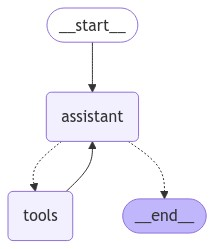

In [19]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [20]:
import shutil
import uuid

# Let's create an example conversation a user might have with the assistant
tutorial_questions = [
    "Hi there, Can you help me find some climbing shoes based on my previous purchases?",
    "I want to do a trekking on the highest base camp in nepal, which trek would you recommend?",
]


thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        # The passenger_id is used in our flight tools to
        # fetch the user's flight information
        "name": "John Doe",
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}


_printed = set()
for question in tutorial_questions:
    events = graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

Hi there, Can you help me find some climbing shoes based on my previous purchases?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_sKseQiPmd1sGUOpzGIrG37Tk)
 Call ID: call_sKseQiPmd1sGUOpzGIrG37Tk
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

customer_interactions
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_0clnj7Kd3G7auYQzC88DfOBk)
 Call ID: call_0clnj7Kd3G7auYQzC88DfOBk
  Args:
    table_names: customer_interactions
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE customer_interactions (
	"Name" TEXT, 
	"Gender" TEXT, 
	"Age" INTEGER, 
	"Previous Purchases" TEXT, 
	"Reviews Given" TEXT
)

/*
3 rows from customer_interactions tabl